In [1]:
import os, json, time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import psutil

tf.random.set_seed(42)
np.random.seed(42)

CLASS_NAMES = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
IMAGE_SIZE = (32, 32)
BATCH_SIZE = 32
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)
process = psutil.Process(os.getpid())

In [2]:
import pandas as pd
from tensorflow.keras.datasets import cifar10

OUT_DIR = "cifar10_data"
os.makedirs(OUT_DIR, exist_ok=True)

def to_dataframe(images, labels):
    labels = labels.reshape(-1)
    flat = images.reshape(len(images), -1)
    col_names = [f"pixel_{i}" for i in range(flat.shape[1])]
    df = pd.DataFrame(flat, columns=col_names)
    df.insert(0, "label", labels)
    df.insert(1, "label_name", [CLASS_NAMES[l] for l in labels])
    return df

(cifar_train_images, cifar_train_labels), (cifar_test_images, cifar_test_labels) = cifar10.load_data()
to_dataframe(cifar_train_images, cifar_train_labels).to_csv(f"{OUT_DIR}/cifar10_train.csv", index=False)
to_dataframe(cifar_test_images, cifar_test_labels).to_csv(f"{OUT_DIR}/cifar10_test.csv", index=False)
print("CSVs ready in cifar10_data/")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1664s 10us/step
CSVs ready in cifar10_data/


In [3]:
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("cifar10_data/cifar10_train.csv")
test_df = pd.read_csv("cifar10_data/cifar10_test.csv")

def df_to_arrays(df):
    labels = df["label"].to_numpy()
    pixel_cols = [c for c in df.columns if c.startswith("pixel_")]
    images = df[pixel_cols].to_numpy().reshape(-1, 32, 32, 3).astype(np.uint8)
    return images, labels

train_images_all, train_labels_all = df_to_arrays(train_df)
test_images, test_labels = df_to_arrays(test_df)

train_images, val_images, train_labels, val_labels = train_test_split(
    train_images_all, train_labels_all, test_size=0.15, random_state=42,
    stratify=train_labels_all)

train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels)) \
    .shuffle(1000, seed=42).batch(BATCH_SIZE)
validation_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels)) \
    .batch(BATCH_SIZE)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset_p = train_dataset.prefetch(AUTOTUNE)
validation_dataset_p = validation_dataset.prefetch(AUTOTUNE)

print("Validation set:", val_images.shape, " Test set:", test_images.shape)

Validation set: (7500, 32, 32, 3)  Test set: (10000, 32, 32, 3)


In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.10),
    layers.RandomBrightness(0.10),
], name="data_augmentation")

In [5]:
def build_cnn_baseline():
    return models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,
        layers.Rescaling(1.0/255),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ], name="cnn_baseline")

build_cnn_baseline().summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
def build_cnn_regularized():
    return models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,
        layers.Rescaling(1.0/255),
        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),
        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.40),
        layers.Dense(10, activation="softmax"),
    ], name="cnn_regularized")

build_cnn_regularized().summary()

Model: "cnn_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

In [7]:
def build_cnn_deep():
    return models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,
        layers.Rescaling(1.0/255),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(10, activation="softmax"),
    ], name="cnn_deep")

build_cnn_deep().summary()

Model: "cnn_deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,122 (617.66 KB)

 Trainable params: 157,674 (615.91 KB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
def make_callbacks(model_name, patience=5):
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
        tf.keras.callbacks.ModelCheckpoint(filepath=f"models/{model_name}.keras", monitor="val_loss", save_best_only=True)
    ]

In [9]:
results = {}

def evaluate_and_record(name, model, mem_before, train_time, epochs_trained):
    probs = model.predict(test_images, batch_size=64, verbose=0)
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(test_labels, preds)
    prec = precision_score(test_labels, preds, average="macro", zero_division=0)
    rec = recall_score(test_labels, preds, average="macro", zero_division=0)
    f1 = f1_score(test_labels, preds, average="macro", zero_division=0)
    cm = confusion_matrix(test_labels, preds)

    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="Blues")
    plt.xticks(range(10), CLASS_NAMES, rotation=90); plt.yticks(range(10), CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"{name} Confusion Matrix")
    plt.colorbar(); plt.tight_layout()
    plt.savefig(f"reports/{name}_confusion_matrix.png", dpi=150, bbox_inches="tight"); plt.show()

    val_probs = model.predict(val_images, batch_size=64, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_acc = accuracy_score(val_labels, val_preds)

    single_image = test_images[0:1]
    _ = model.predict(single_image, verbose=0)
    latencies = []
    for _ in range(100):
        t_start = time.time()
        model.predict(single_image, verbose=0)
        latencies.append((time.time() - t_start) * 1000)
    latencies = np.array(latencies)

    n_throughput = min(1000, len(test_images))
    t_start = time.time()
    model.predict(test_images[:n_throughput], batch_size=64, verbose=0)
    throughput = n_throughput / (time.time() - t_start)

    model_size_mb = os.path.getsize(f"models/{name}.keras") / (1024*1024)
    param_count = model.count_params()
    mem_after = process.memory_info().rss / (1024*1024)

    results[name] = {
        "epochs_trained": epochs_trained, "train_time_sec": train_time,
        "test_accuracy": float(acc), "test_precision_macro": float(prec),
        "test_recall_macro": float(rec), "test_f1_macro": float(f1),
        "validation_accuracy": float(val_acc), "confusion_matrix": cm.tolist(),
        "latency_ms_avg": float(latencies.mean()), "latency_ms_min": float(latencies.min()),
        "latency_ms_max": float(latencies.max()), "throughput_img_per_sec": float(throughput),
        "model_size_mb": float(model_size_mb), "param_count": int(param_count),
        "memory_delta_mb": float(mem_after - mem_before),
    }
    print(f"{name}: acc={acc:.4f} prec={prec:.4f} rec={rec:.4f} f1={f1:.4f} val_acc={val_acc:.4f}")
    print(f"{name}: latency_avg={latencies.mean():.2f}ms throughput={throughput:.1f}img/s "
          f"size={model_size_mb:.2f}MB params={param_count}")
    with open("reports/individual_results.json", "w") as f:
        json.dump(results, f, indent=2)

In [10]:
def plot_history(history, name):
    epochs_range = range(1, len(history.history["accuracy"]) + 1)
    plt.figure(figsize=(7,4))
    plt.plot(epochs_range, history.history["accuracy"], label="Training Accuracy")
    plt.plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.title(f"{name} — Training vs Validation Accuracy")
    plt.savefig(f"reports/{name}_accuracy_graph.png", dpi=150, bbox_inches="tight"); plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs_range, history.history["loss"], label="Training Loss")
    plt.plot(epochs_range, history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.title(f"{name} — Training vs Validation Loss")
    plt.savefig(f"reports/{name}_loss_graph.png", dpi=150, bbox_inches="tight"); plt.show()

Epoch 1/30
1329/1329 - 19s - 15ms/step - accuracy: 0.3930 - loss: 1.6667 - val_accuracy: 0.4944 - val_loss: 1.3945 - learning_rate: 0.0010
Epoch 2/30
1329/1329 - 11s - 8ms/step - accuracy: 0.4934 - loss: 1.4205 - val_accuracy: 0.5479 - val_loss: 1.2395 - learning_rate: 0.0010
Epoch 3/30
1329/1329 - 9s - 7ms/step - accuracy: 0.5317 - loss: 1.3196 - val_accuracy: 0.5828 - val_loss: 1.1742 - learning_rate: 0.0010
Epoch 4/30
1329/1329 - 11s - 8ms/step - accuracy: 0.5557 - loss: 1.2493 - val_accuracy: 0.5684 - val_loss: 1.2758 - learning_rate: 0.0010
Epoch 5/30
1329/1329 - 11s - 8ms/step - accuracy: 0.5754 - loss: 1.2026 - val_accuracy: 0.6065 - val_loss: 1.1393 - learning_rate: 0.0010
Epoch 6/30
1329/1329 - 11s - 8ms/step - accuracy: 0.5871 - loss: 1.1680 - val_accuracy: 0.6296 - val_loss: 1.0614 - learning_rate: 0.0010
Epoch 7/30
1329/1329 - 11s - 8ms/step - accuracy: 0.5952 - loss: 1.1427 - val_accuracy: 0.6268 - val_loss: 1.0853 - learning_rate: 0.0010
Epoch 8/30
1329/1329 - 10s - 8ms/s

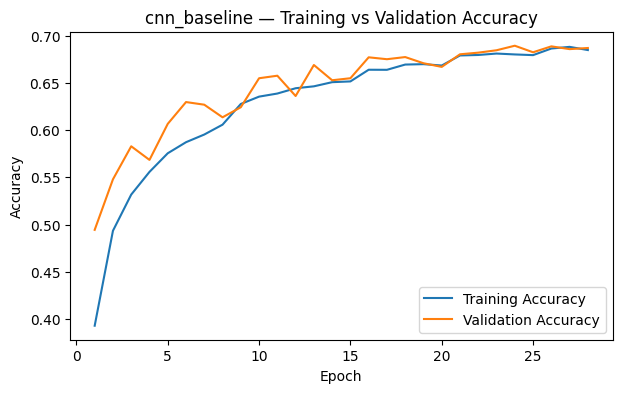

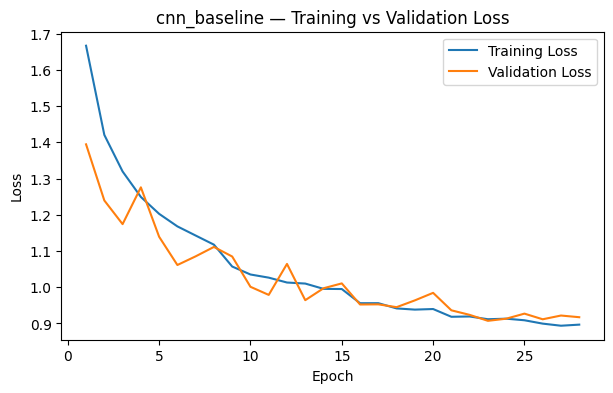

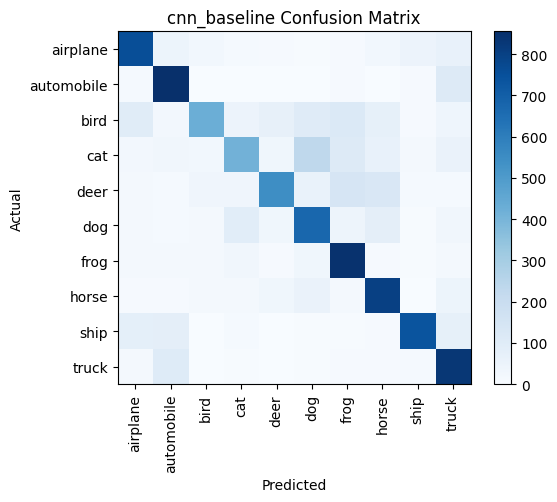

cnn_baseline: acc=0.6883 prec=0.6968 rec=0.6883 f1=0.6799 val_acc=0.6844
cnn_baseline: latency_avg=80.91ms throughput=6116.8img/s size=1.97MB params=167562


In [11]:
mem_before = process.memory_info().rss / (1024*1024)
cnn_baseline = build_cnn_baseline()
cnn_baseline.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
t0 = time.time()
history_baseline = cnn_baseline.fit(train_dataset_p, validation_data=validation_dataset_p,
                                     epochs=30, callbacks=make_callbacks("cnn_baseline"), verbose=2)
train_time_baseline = time.time() - t0
plot_history(history_baseline, "cnn_baseline")
evaluate_and_record("cnn_baseline", cnn_baseline, mem_before, train_time_baseline, len(history_baseline.history["accuracy"]))

Epoch 1/30
1329/1329 - 20s - 15ms/step - accuracy: 0.1608 - loss: 2.1691 - val_accuracy: 0.2391 - val_loss: 1.9215 - learning_rate: 0.0010
Epoch 2/30
1329/1329 - 14s - 11ms/step - accuracy: 0.1865 - loss: 2.0360 - val_accuracy: 0.2599 - val_loss: 1.8886 - learning_rate: 0.0010
Epoch 3/30
1329/1329 - 20s - 15ms/step - accuracy: 0.2001 - loss: 2.0183 - val_accuracy: 0.2361 - val_loss: 1.9081 - learning_rate: 0.0010
Epoch 4/30
1329/1329 - 21s - 16ms/step - accuracy: 0.2057 - loss: 2.0060 - val_accuracy: 0.1156 - val_loss: 2.7569 - learning_rate: 0.0010
Epoch 5/30
1329/1329 - 14s - 10ms/step - accuracy: 0.2095 - loss: 1.9904 - val_accuracy: 0.2904 - val_loss: 1.8251 - learning_rate: 5.0000e-04
Epoch 6/30
1329/1329 - 14s - 11ms/step - accuracy: 0.2180 - loss: 1.9817 - val_accuracy: 0.2991 - val_loss: 1.7878 - learning_rate: 5.0000e-04
Epoch 7/30
1329/1329 - 14s - 11ms/step - accuracy: 0.2204 - loss: 1.9820 - val_accuracy: 0.3333 - val_loss: 1.7493 - learning_rate: 5.0000e-04
Epoch 8/30
1329

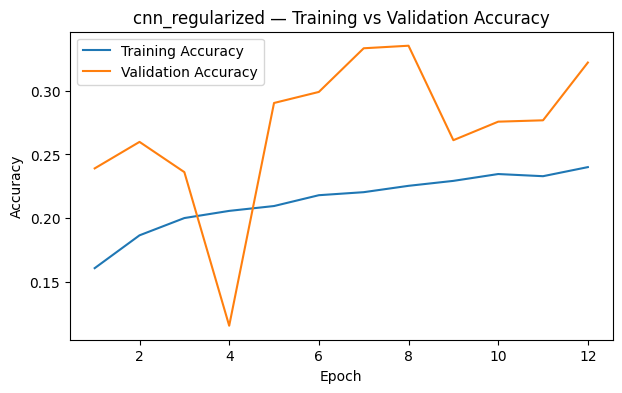

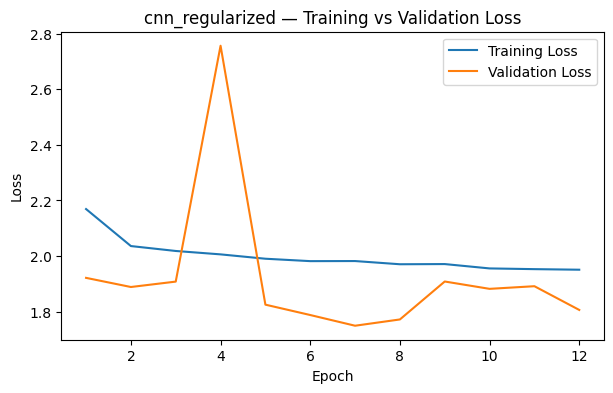

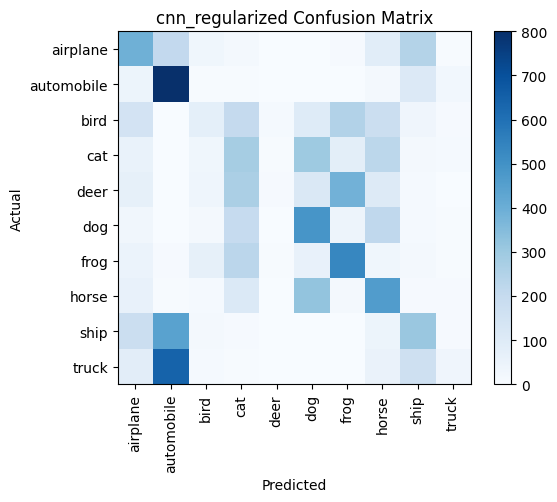

cnn_regularized: acc=0.3373 prec=0.3115 rec=0.3373 f1=0.2887 val_acc=0.3333
cnn_regularized: latency_avg=83.92ms throughput=5568.6img/s size=6.32MB params=545482


In [12]:
mem_before = process.memory_info().rss / (1024*1024)
cnn_regularized = build_cnn_regularized()
cnn_regularized.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                         loss="sparse_categorical_crossentropy", metrics=["accuracy"])
t0 = time.time()
history_regularized = cnn_regularized.fit(train_dataset_p, validation_data=validation_dataset_p,
                                           epochs=30, callbacks=make_callbacks("cnn_regularized"), verbose=2)
train_time_regularized = time.time() - t0
plot_history(history_regularized, "cnn_regularized")
evaluate_and_record("cnn_regularized", cnn_regularized, mem_before, train_time_regularized, len(history_regularized.history["accuracy"]))

Epoch 1/20
1329/1329 - 24s - 18ms/step - accuracy: 0.4297 - loss: 1.5646 - val_accuracy: 0.3719 - val_loss: 1.9522 - learning_rate: 0.0010
Epoch 2/20
1329/1329 - 19s - 14ms/step - accuracy: 0.5617 - loss: 1.2340 - val_accuracy: 0.5576 - val_loss: 1.2879 - learning_rate: 0.0010
Epoch 3/20
1329/1329 - 18s - 14ms/step - accuracy: 0.6142 - loss: 1.0905 - val_accuracy: 0.5517 - val_loss: 1.2989 - learning_rate: 0.0010
Epoch 4/20
1329/1329 - 18s - 14ms/step - accuracy: 0.6469 - loss: 1.0055 - val_accuracy: 0.5632 - val_loss: 1.3643 - learning_rate: 0.0010
Epoch 5/20
1329/1329 - 20s - 15ms/step - accuracy: 0.6908 - loss: 0.8911 - val_accuracy: 0.6541 - val_loss: 1.0337 - learning_rate: 5.0000e-04
Epoch 6/20
1329/1329 - 18s - 13ms/step - accuracy: 0.7043 - loss: 0.8509 - val_accuracy: 0.6476 - val_loss: 1.0422 - learning_rate: 5.0000e-04
Epoch 7/20
1329/1329 - 19s - 15ms/step - accuracy: 0.7176 - loss: 0.8172 - val_accuracy: 0.6564 - val_loss: 1.0585 - learning_rate: 5.0000e-04
Epoch 8/20
1329

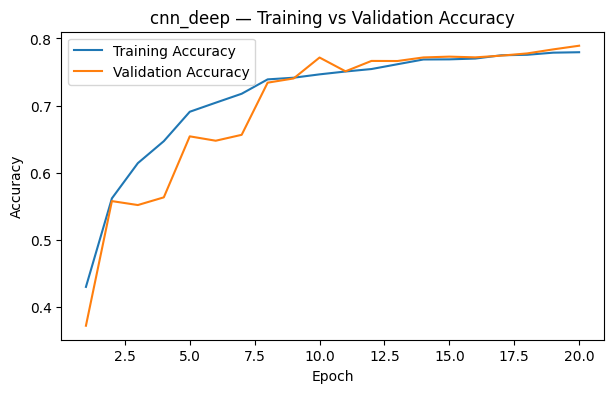

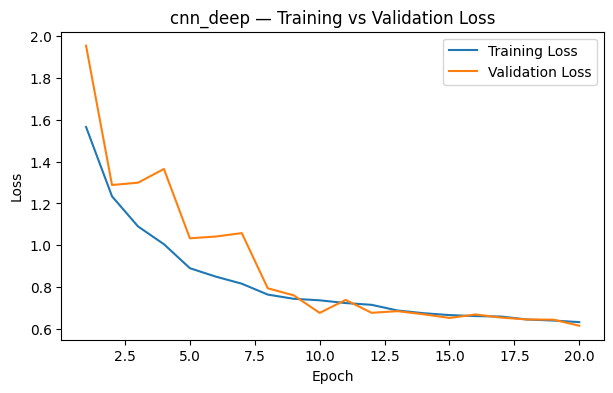

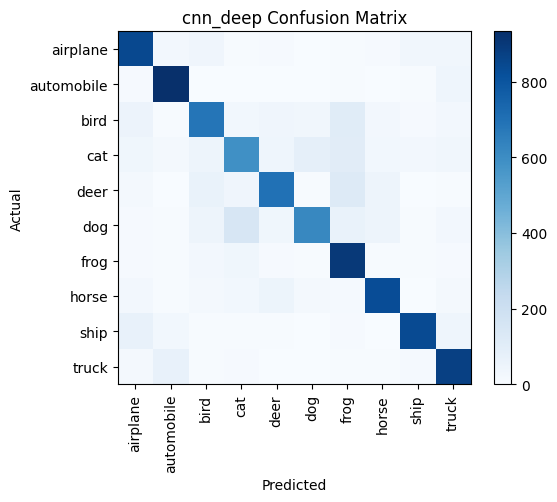

cnn_deep: acc=0.7800 prec=0.7825 rec=0.7800 f1=0.7772 val_acc=0.7892
cnn_deep: latency_avg=81.65ms throughput=1956.9img/s size=1.90MB params=158122


In [13]:
mem_before = process.memory_info().rss / (1024*1024)
cnn_deep = build_cnn_deep()
cnn_deep.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
t0 = time.time()
history_deep = cnn_deep.fit(train_dataset_p, validation_data=validation_dataset_p,
                             epochs=20, callbacks=make_callbacks("cnn_deep", patience=4), verbose=2)
train_time_deep = time.time() - t0
plot_history(history_deep, "cnn_deep")
evaluate_and_record("cnn_deep", cnn_deep, mem_before, train_time_deep, len(history_deep.history["accuracy"]))

In [14]:
trained_models = {"cnn_baseline": cnn_baseline, "cnn_regularized": cnn_regularized, "cnn_deep": cnn_deep}
model_names = list(trained_models.keys())

all_probs = {name: trained_models[name].predict(test_images, batch_size=64, verbose=0) for name in model_names}
all_preds = {name: np.argmax(all_probs[name], axis=1) for name in model_names}

In [15]:
stacked_preds = np.stack([all_preds[name] for name in model_names], axis=1)
majority_preds = np.array([np.bincount(row, minlength=10).argmax() for row in stacked_preds])

In [16]:
soft_probs = np.mean([all_probs[name] for name in model_names], axis=0)
soft_preds = np.argmax(soft_probs, axis=1)

In [17]:
val_accs = np.array([results[name]["validation_accuracy"] for name in model_names])
weights = val_accs / val_accs.sum()
print("Ensemble weights (from validation accuracy):", dict(zip(model_names, weights)))

weighted_probs = np.zeros_like(soft_probs)
for i, name in enumerate(model_names):
    weighted_probs += weights[i] * all_probs[name]
weighted_preds = np.argmax(weighted_probs, axis=1)

Ensemble weights (from validation accuracy): {'cnn_baseline': np.float64(0.3787632821723731), 'cnn_regularized': np.float64(0.1844746162927981), 'cnn_deep': np.float64(0.4367621015348288)}


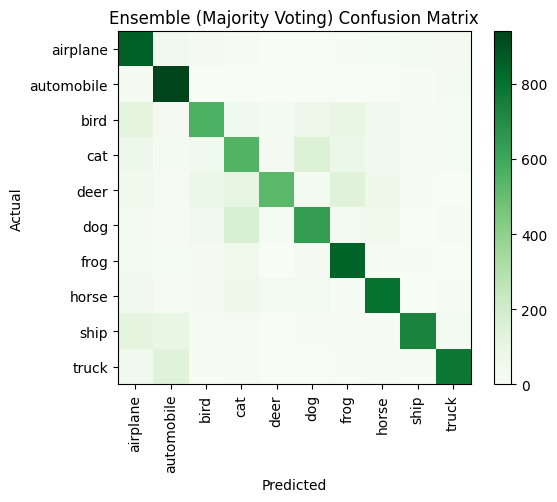

Majority Voting: acc=0.7222 prec=0.7349 rec=0.7222 f1=0.7191


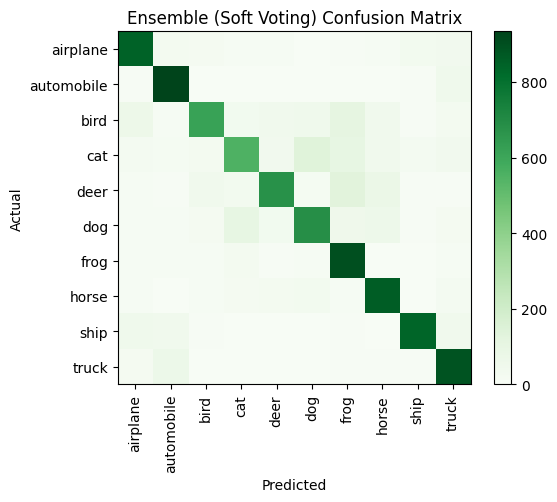

Soft Voting: acc=0.7788 prec=0.7817 rec=0.7788 f1=0.7747


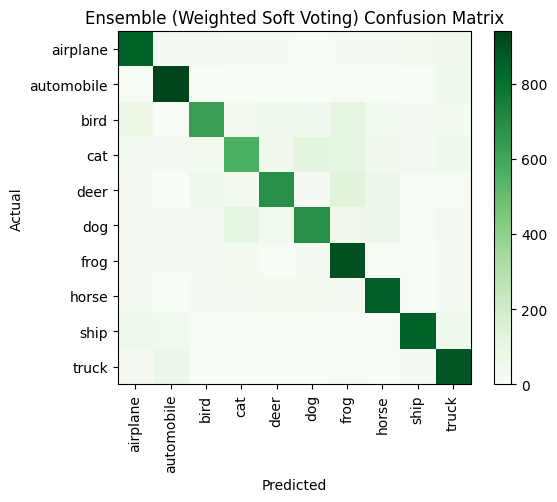

Weighted Soft Voting: acc=0.7845 prec=0.7872 rec=0.7845 f1=0.7807


In [18]:
def eval_ensemble(preds, label):
    acc = accuracy_score(test_labels, preds)
    prec = precision_score(test_labels, preds, average="macro", zero_division=0)
    rec = recall_score(test_labels, preds, average="macro", zero_division=0)
    f1 = f1_score(test_labels, preds, average="macro", zero_division=0)
    cm = confusion_matrix(test_labels, preds)

    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="Greens")
    plt.xticks(range(10), CLASS_NAMES, rotation=90); plt.yticks(range(10), CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Ensemble ({label}) Confusion Matrix")
    plt.colorbar(); plt.tight_layout()
    fname = label.lower().replace(" ", "_")
    plt.savefig(f"reports/ensemble_{fname}_confusion_matrix.png", dpi=150, bbox_inches="tight"); plt.show()

    print(f"{label}: acc={acc:.4f} prec={prec:.4f} rec={rec:.4f} f1={f1:.4f}")
    return {"accuracy": float(acc), "precision_macro": float(prec), "recall_macro": float(rec),
            "f1_macro": float(f1), "confusion_matrix": cm.tolist()}

ensemble_results = {
    "majority_voting": eval_ensemble(majority_preds, "Majority Voting"),
    "soft_voting": eval_ensemble(soft_preds, "Soft Voting"),
    "weighted_soft_voting": eval_ensemble(weighted_preds, "Weighted Soft Voting"),
    "weights_used": {model_names[i]: float(weights[i]) for i in range(len(model_names))},
}

In [19]:
all_agree = np.all(stacked_preds == stacked_preds[:, [0]], axis=1)
best_individual = max(model_names, key=lambda n: results[n]["test_accuracy"])
best_individual_wrong = (all_preds[best_individual] != test_labels)

ensemble_rescued = int(np.sum(best_individual_wrong & (soft_preds == test_labels)))
ensemble_hurt = int(np.sum((~best_individual_wrong) & (soft_preds != test_labels)))

disagreement_analysis = {
    "full_agreement_rate": float(all_agree.mean()),
    "disagreement_rate": float(1 - all_agree.mean()),
    "best_individual_model": best_individual,
    "cases_ensemble_fixed_best_individual_mistake": ensemble_rescued,
    "cases_ensemble_introduced_new_mistake": ensemble_hurt,
}
print(json.dumps(disagreement_analysis, indent=2))

{
  "full_agreement_rate": 0.2927,
  "disagreement_rate": 0.7073,
  "best_individual_model": "cnn_deep",
  "cases_ensemble_fixed_best_individual_mistake": 428,
  "cases_ensemble_introduced_new_mistake": 440
}


In [20]:
single_image = test_images[0:1]
ensemble_latencies = []
for _ in range(100):
    t_start = time.time()
    for name in model_names:
        trained_models[name].predict(single_image, verbose=0)
    ensemble_latencies.append((time.time() - t_start) * 1000)
ensemble_latencies = np.array(ensemble_latencies)

n_throughput = min(1000, len(test_images))
t_start = time.time()
for name in model_names:
    trained_models[name].predict(test_images[:n_throughput], batch_size=64, verbose=0)
ensemble_throughput = n_throughput / (time.time() - t_start)

ensemble_benchmark = {
    "latency_ms_avg": float(ensemble_latencies.mean()),
    "latency_ms_min": float(ensemble_latencies.min()),
    "latency_ms_max": float(ensemble_latencies.max()),
    "throughput_img_per_sec": float(ensemble_throughput),
    "total_model_size_mb": float(sum(results[n]["model_size_mb"] for n in model_names)),
    "total_param_count": int(sum(results[n]["param_count"] for n in model_names)),
    "approx_memory_mb": float(sum(results[n]["memory_delta_mb"] for n in model_names)),
}
print(json.dumps(ensemble_benchmark, indent=2))

{
  "latency_ms_avg": 248.7393617630005,
  "latency_ms_min": 198.15969467163086,
  "latency_ms_max": 738.9402389526367,
  "throughput_img_per_sec": 1667.959367414397,
  "total_model_size_mb": 10.18515682220459,
  "total_param_count": 871166,
  "approx_memory_mb": -208.2578125
}


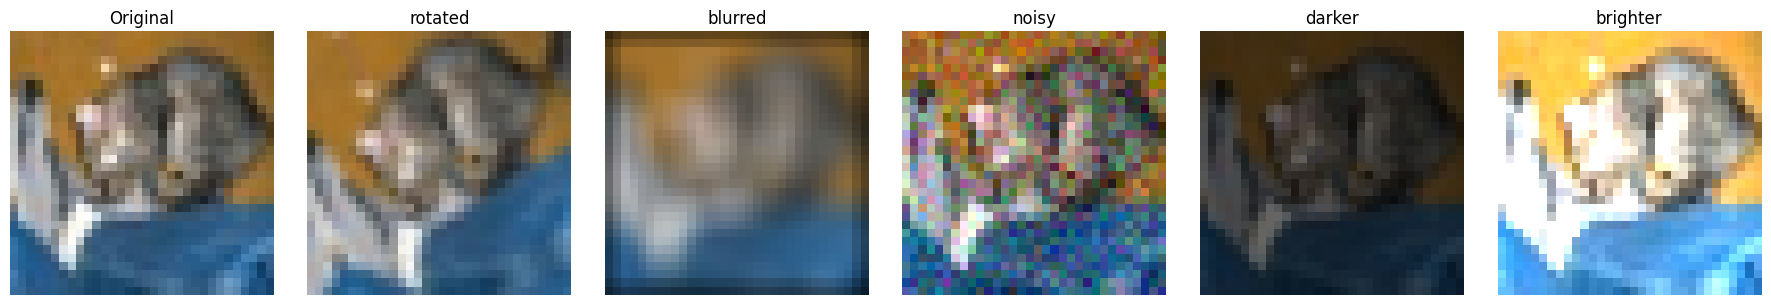

In [21]:
def make_rotated(images):
    return tf.keras.layers.RandomRotation((25/360, 25/360))(images, training=True).numpy()

def make_blurred(images):
    imgs = tf.convert_to_tensor(images, dtype=tf.float32)
    kernel = tf.ones((5,5,3,1), dtype=tf.float32) / 25.0
    blurred = tf.nn.depthwise_conv2d(imgs, kernel, strides=[1,1,1,1], padding="SAME")
    return np.clip(blurred.numpy(), 0, 255).astype(np.uint8)

def make_noisy(images, sigma=20):
    noise = np.random.normal(0, sigma, images.shape)
    return np.clip(images.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def make_darker(images, factor=0.4):
    return np.clip(images.astype(np.float32) * factor, 0, 255).astype(np.uint8)

def make_brighter(images, factor=1.8):
    return np.clip(images.astype(np.float32) * factor, 0, 255).astype(np.uint8)

corruptions = {
    "rotated": make_rotated(test_images.astype(np.float32)),
    "blurred": make_blurred(test_images),
    "noisy": make_noisy(test_images),
    "darker": make_darker(test_images),
    "brighter": make_brighter(test_images),
}

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(test_images[0].astype(np.uint8)); axes[0].set_title("Original"); axes[0].axis("off")
for i, (name, imgs) in enumerate(corruptions.items(), start=1):
    axes[i].imshow(imgs[0].astype(np.uint8)); axes[i].set_title(name); axes[i].axis("off")
plt.tight_layout()
plt.savefig("reports/robustness_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
robustness_results = {}
for corruption_name, corrupted_images in corruptions.items():
    row = {}
    corrupted_probs = {}
    for name in model_names:
        probs = trained_models[name].predict(corrupted_images, batch_size=64, verbose=0)
        preds = np.argmax(probs, axis=1)
        row[name] = float(accuracy_score(test_labels, preds))
        corrupted_probs[name] = probs
    soft_corrupt_probs = np.mean([corrupted_probs[n] for n in model_names], axis=0)
    soft_corrupt_preds = np.argmax(soft_corrupt_probs, axis=1)
    row["ensemble_soft_voting"] = float(accuracy_score(test_labels, soft_corrupt_preds))
    robustness_results[corruption_name] = row
    print(f"{corruption_name}: {row}")

rotated: {'cnn_baseline': 0.6431, 'cnn_regularized': 0.3242, 'cnn_deep': 0.7364, 'ensemble_soft_voting': 0.7402}
blurred: {'cnn_baseline': 0.4966, 'cnn_regularized': 0.2352, 'cnn_deep': 0.407, 'ensemble_soft_voting': 0.4762}
noisy: {'cnn_baseline': 0.571, 'cnn_regularized': 0.2745, 'cnn_deep': 0.3825, 'ensemble_soft_voting': 0.5298}
darker: {'cnn_baseline': 0.5909, 'cnn_regularized': 0.1506, 'cnn_deep': 0.7402, 'ensemble_soft_voting': 0.7326}
brighter: {'cnn_baseline': 0.5877, 'cnn_regularized': 0.2796, 'cnn_deep': 0.6589, 'ensemble_soft_voting': 0.6675}


In [23]:
final_summary = {
    "individual_models": results,
    "ensemble": ensemble_results,
    "ensemble_benchmark": ensemble_benchmark,
    "disagreement_analysis": disagreement_analysis,
    "robustness": robustness_results,
    "best_individual_model": best_individual,
}
with open("reports/final_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2)

print("Best individual model:", best_individual, "-", results[best_individual]["test_accuracy"])
print("Best ensemble strategy:", max(
    [(k,v) for k,v in ensemble_results.items() if k != "weights_used"],
    key=lambda kv: kv[1]["accuracy"]
)[0])

Best individual model: cnn_deep - 0.78
Best ensemble strategy: weighted_soft_voting
